### Sentiment, Inconsistency & Recommendation Analysis



In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'sans-serif'})


In [2]:
df = pd.read_csv('../Datasets/Amazon_Product_Review_Cleaned.csv')
df['reviews.numHelpful'] = df['reviews.numHelpful'].fillna(0)
print(f'Shape: {df.shape}')
df[['name', 'device_type', 'reviews.rating', 'sentiment', 'price_usd']].head()


Shape: (1597, 28)


,name,device_type,reviews.rating,sentiment,price_usd
0,Kindle Paperwhite,Kindle,5.0,Positive,139.99
1,Kindle Paperwhite,Kindle,5.0,Positive,139.99
2,Kindle Paperwhite,Kindle,4.0,Positive,139.99
3,Kindle Paperwhite,Kindle,5.0,Positive,139.99
4,Kindle Paperwhite,Kindle,5.0,Positive,139.99



## Section 3 Sentiment Categorisation



In [3]:
print(df['sentiment'].value_counts().to_string())


sentiment
Positive    1369
Neutral      152
Negative      76


### 3a  Rating Distribution (Histogram)

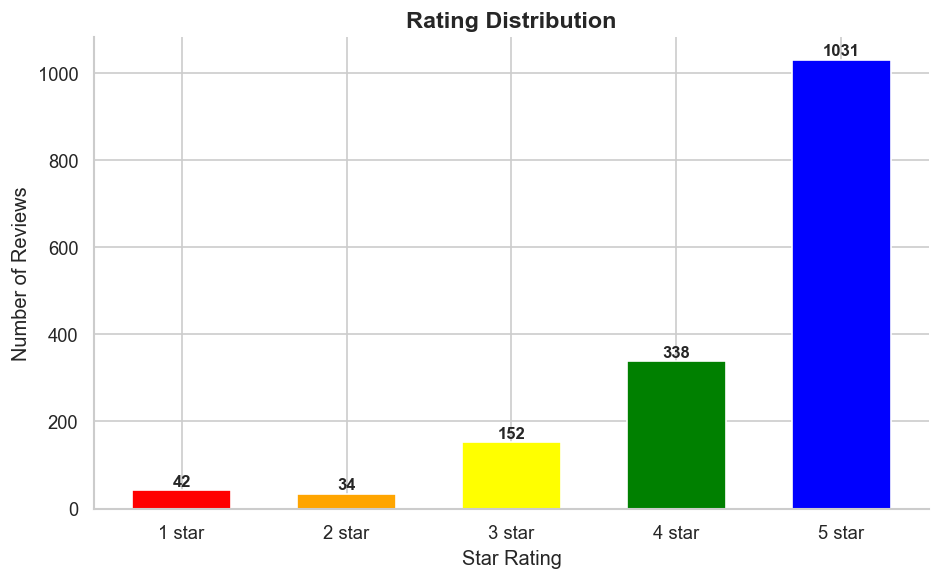

In [4]:
rating_counts = df['reviews.rating'].value_counts().sort_index()
colors = ['red', 'orange', 'yellow', 'green', 'blue']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(rating_counts.index.astype(int), rating_counts.values,
              color=colors, width=0.6, edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            str(int(bar.get_height())), ha='center', fontsize=10, fontweight='bold')

ax.set_title('Rating Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Star Rating')
ax.set_ylabel('Number of Reviews')
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['1 star', '2 star', '3 star', '4 star', '5 star'])
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/charts/s3_hist_ratings.png', dpi=150)
plt.show()


### 3b — Top Reviewed Products (Bar Plot)

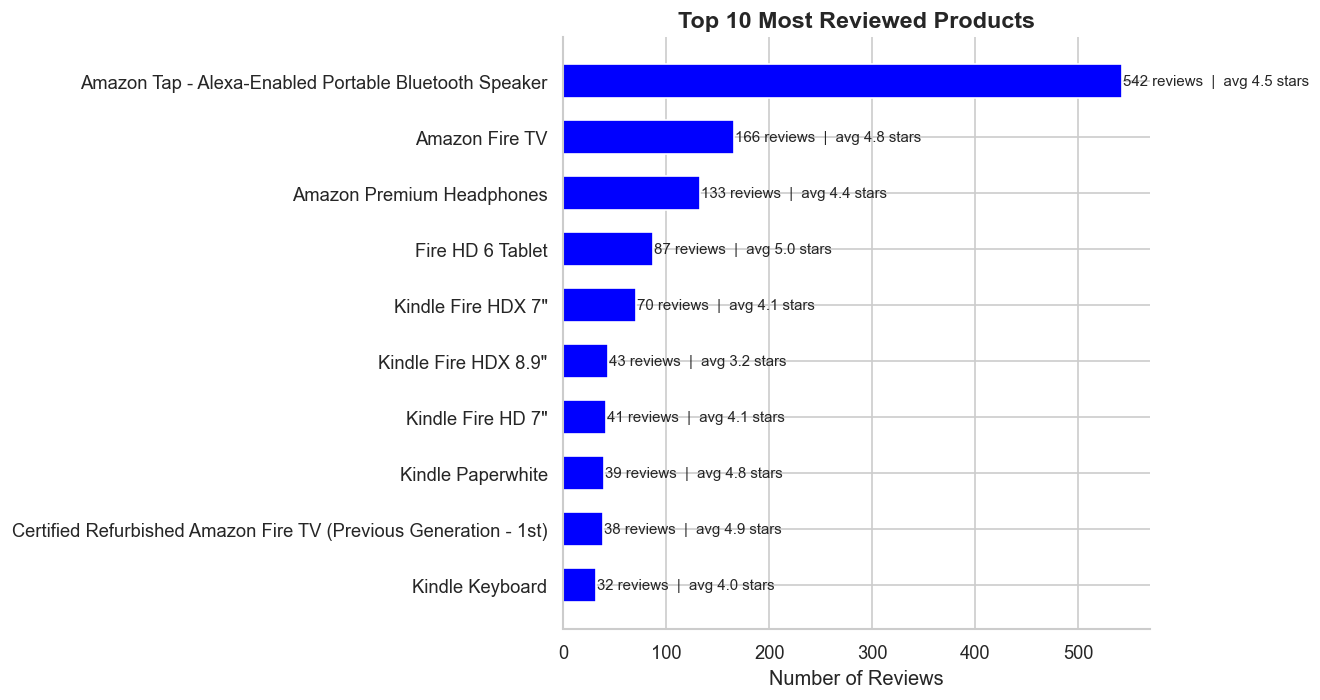

In [15]:
top10 = (
    df.groupby('name')['reviews.rating']
      .agg(['count', 'mean'])
      .rename(columns={'count': 'reviews', 'mean': 'avg_rating'})
      .sort_values('reviews', ascending=False)
      .head(10)
)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top10.index[::-1], top10['reviews'][::-1],
               color='blue', height=0.6, edgecolor='white')
for bar, (_, row) in zip(bars, top10[::-1].iterrows()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width())} reviews  |  avg {row['avg_rating']:.1f} stars",
            va='center', fontsize=9)

ax.set_title('Top 10 Most Reviewed Products', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Reviews')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/charts/s3_bar_top_products.png', dpi=150)
plt.show()


### 3c — Review Correlations (Heatmap)

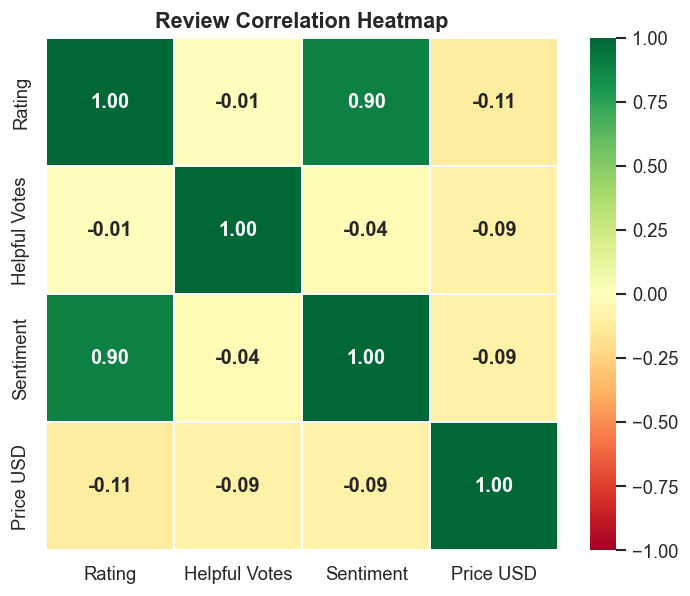

In [6]:
df['sentiment_score'] = df['sentiment'].map({'Positive': 1, 'Neutral': 0, 'Negative': -1})

corr = df[['reviews.rating', 'reviews.numHelpful', 'sentiment_score', 'price_usd']].rename(columns={
    'reviews.rating': 'Rating',
    'reviews.numHelpful': 'Helpful Votes',
    'sentiment_score': 'Sentiment',
    'price_usd': 'Price USD'
}).corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1,
            linewidths=1.2, linecolor='white', square=True,
            annot_kws={'size': 12, 'weight': 'bold'}, ax=ax)
ax.set_title('Review Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/s3_heatmap.png', dpi=150)
plt.show()



## Section 4 — Products with Inconsistent Ratings



In [7]:
rating_stats = (
    df.groupby('name')['reviews.rating']
      .agg(['mean', 'std', 'count'])
      .rename(columns={'mean': 'avg', 'std': 'std_dev', 'count': 'reviews'})
      .dropna(subset=['std_dev'])
      .query('reviews >= 10')
      .sort_values('std_dev', ascending=False)
)
print('Top inconsistent products:')
print(rating_stats.head(10).round(2).to_string())


Top inconsistent products:
                                                                                            avg  std_dev  reviews
name                                                                                                             
Moshi Anti-Glare No Bubble Screen Protector for the Fire Phone                             3.33     1.92       12
Replacement Remote for Amazon Fire TV Stick                                                2.53     1.66       17
All-New Amazon Fire 7 Tablet Case (7th Generation                                          3.78     1.55       27
Amazon 5W USB Official OEM Charger and Power Adapter for Fire Tablets and Kindle eReaders  3.84     1.50       19
Amazon Fire TV Game Controller                                                             3.91     1.45       11
Amazon Kindle Oasis Premium Leather Battery Cover - Walnut                                 3.67     1.37       12
All-New Amazon Fire HD 8 Tablet Case (7th Generation         

### 4a — Std Dev Distribution (Histogram)

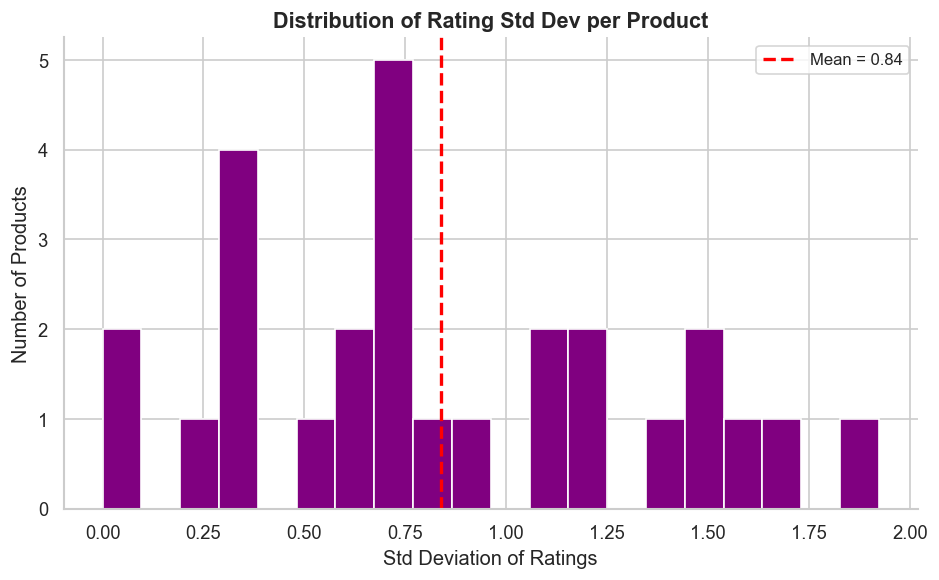

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(rating_stats['std_dev'], bins=20, color='purple', edgecolor='white')
ax.axvline(rating_stats['std_dev'].mean(), color='red', linewidth=2,
           linestyle='--', label=f"Mean = {rating_stats['std_dev'].mean():.2f}")
ax.set_title('Distribution of Rating Std Dev per Product', fontsize=13, fontweight='bold')
ax.set_xlabel('Std Deviation of Ratings')
ax.set_ylabel('Number of Products')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/charts/s4_hist_inconsistency.png', dpi=150)
plt.show()


### 4b — Most Inconsistent Products (Bar Plot)

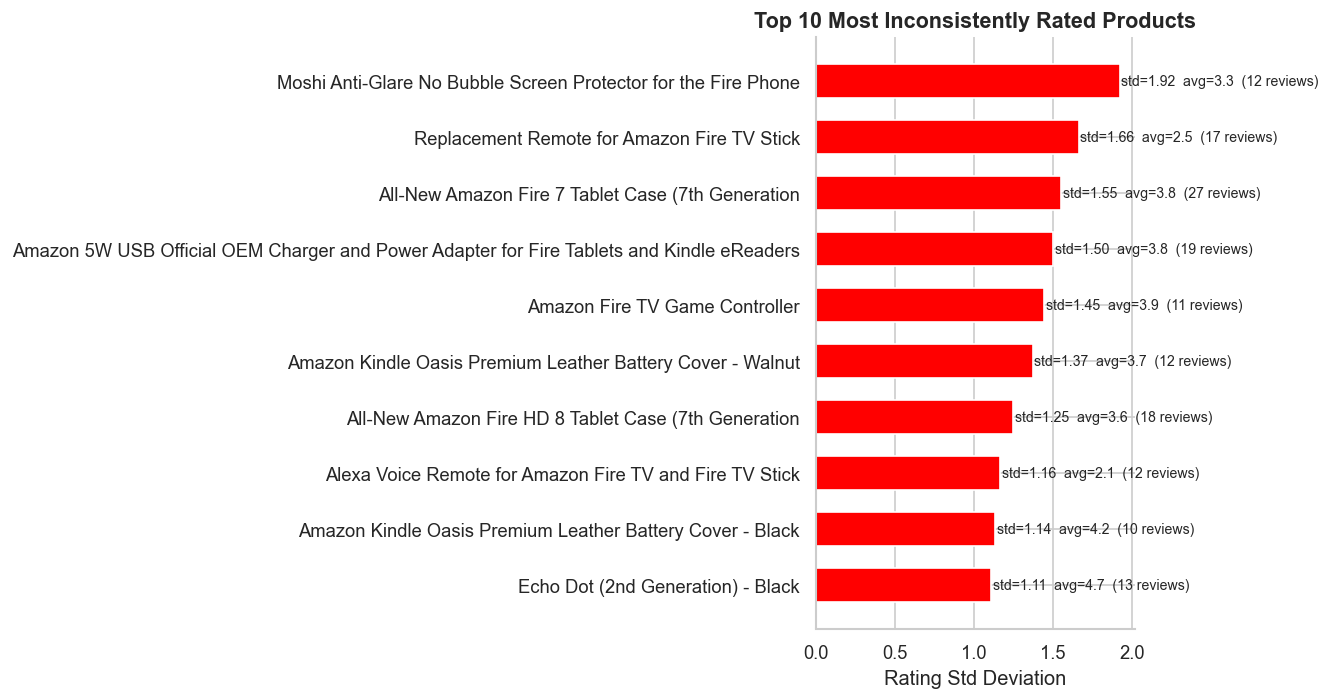

In [17]:
top_inc = rating_stats.head(10).reset_index()

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_inc['name'][::-1], top_inc['std_dev'][::-1],
               color='red', height=0.6, edgecolor='white')
for bar, row in zip(bars, top_inc[::-1].itertuples()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"std={row.std_dev:.2f}  avg={row.avg:.1f}  ({int(row.reviews)} reviews)",
            va='center', fontsize=8.5)

ax.set_title('Top 10 Most Inconsistently Rated Products', fontsize=13, fontweight='bold')
ax.set_xlabel('Rating Std Deviation')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/charts/s4_bar_inconsistent.png', dpi=150)
plt.show()


### 4c — Correlations for Inconsistent Products (Heatmap)

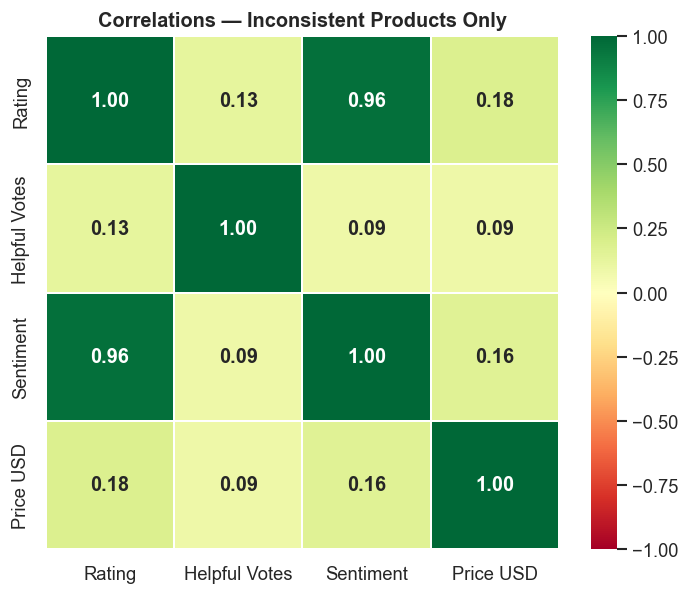

In [10]:
inconsistent_names = rating_stats.head(10).index.tolist()
df_inc = df[df['name'].isin(inconsistent_names)].copy()
df_inc['sentiment_score'] = df_inc['sentiment'].map({'Positive': 1, 'Neutral': 0, 'Negative': -1})

corr_inc = df_inc[['reviews.rating', 'reviews.numHelpful', 'sentiment_score', 'price_usd']].rename(columns={
    'reviews.rating': 'Rating',
    'reviews.numHelpful': 'Helpful Votes',
    'sentiment_score': 'Sentiment',
    'price_usd': 'Price USD'
}).corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_inc, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1,
            linewidths=1.2, linecolor='white', square=True,
            annot_kws={'size': 12, 'weight': 'bold'}, ax=ax)
ax.set_title('Correlations — Inconsistent Products Only', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/s4_heatmap_inconsistent.png', dpi=150)
plt.show()


=
## Section 5 — Recommended vs Not Recommended



In [11]:
df_rec = df[df['reviews.doRecommend'] == True]
df_not = df[df['reviews.doRecommend'] == False]

print(f"Recommended:     {len(df_rec)} reviews  |  avg rating: {df_rec['reviews.rating'].mean():.2f}")
print(f"Not recommended: {len(df_not)} reviews  |  avg rating: {df_not['reviews.rating'].mean():.2f}")


Recommended:     503 reviews  |  avg rating: 4.67
Not recommended: 36 reviews  |  avg rating: 2.61


### 5a — Rating Distribution Comparison (Histogram)

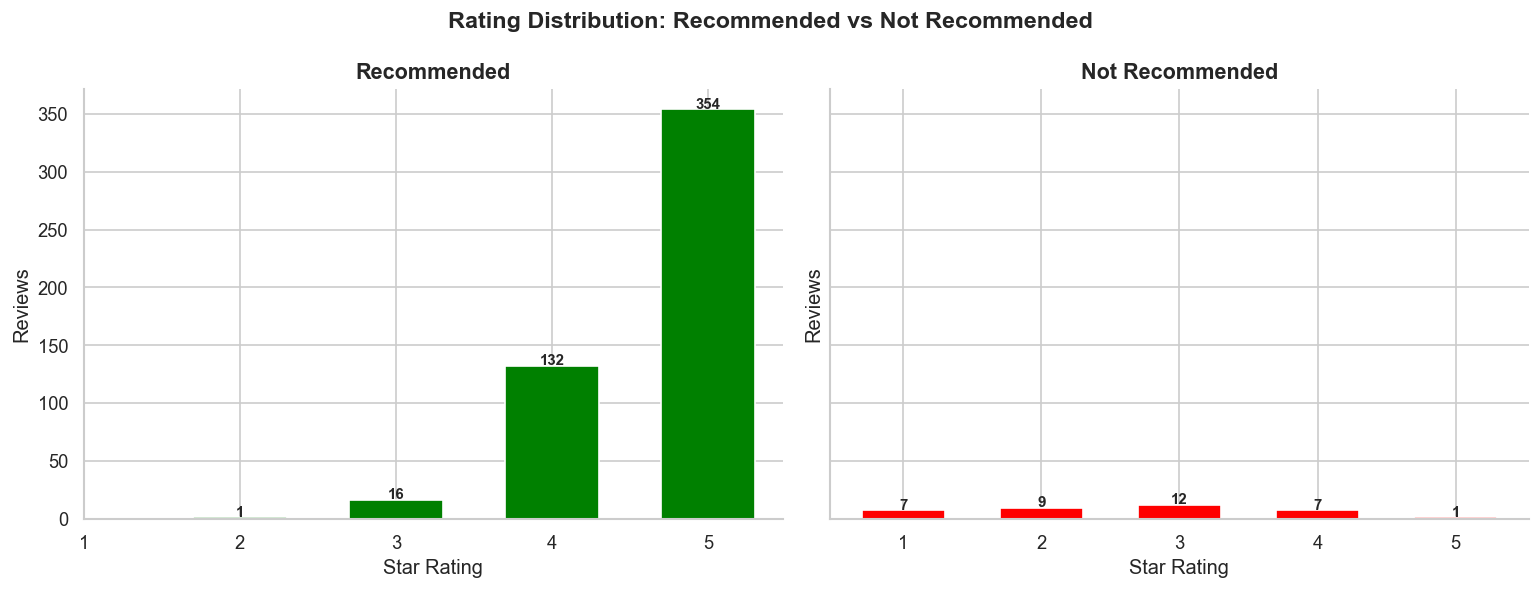

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, subset, label, color in zip(
    axes,
    [df_rec, df_not],
    ['Recommended', 'Not Recommended'],
    ['green', 'red']
):
    counts = subset['reviews.rating'].value_counts().sort_index()
    ax.bar(counts.index.astype(int), counts.values, color=color, edgecolor='white', width=0.6)
    for x, y in zip(counts.index.astype(int), counts.values):
        ax.text(x, y + 1, str(y), ha='center', fontsize=9, fontweight='bold')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Star Rating')
    ax.set_ylabel('Reviews')
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Rating Distribution: Recommended vs Not Recommended', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/s5_hist_rec_vs_not.png', dpi=150)
plt.show()


### 5b — Avg Rating per Product (Bar Plot)

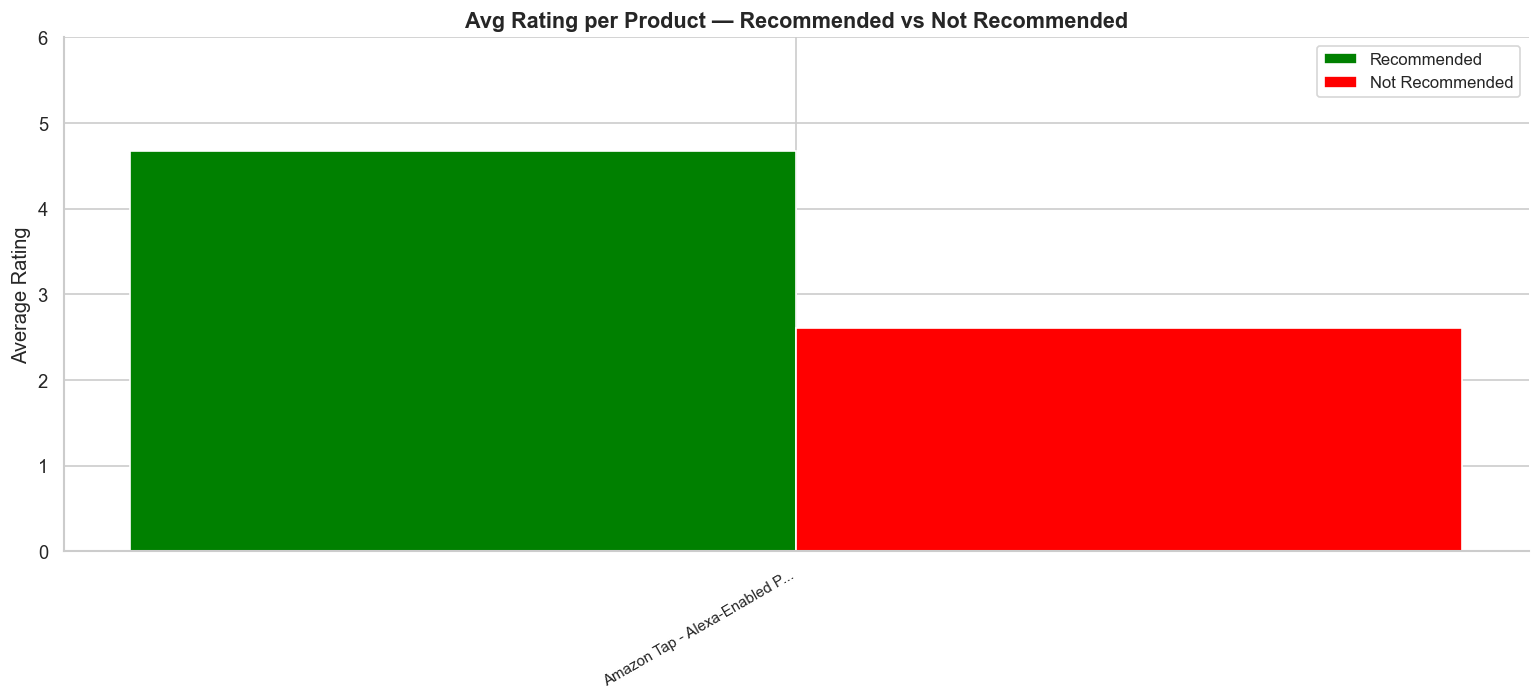

In [19]:
top_names = df['name'].value_counts().head(10).index.tolist()

rec_avg = df_rec[df_rec['name'].isin(top_names)].groupby('name')['reviews.rating'].mean().rename('Recommended')
not_avg = df_not[df_not['name'].isin(top_names)].groupby('name')['reviews.rating'].mean().rename('Not Recommended')

compare = pd.concat([rec_avg, not_avg], axis=1).reindex(top_names).dropna()
short_names = [n[:28] + '...' if len(n) > 28 else n for n in compare.index]

x = np.arange(len(compare))
w = 0.38

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - w/2, compare['Recommended'],     width=w, color='green', label='Recommended',     edgecolor='white')
ax.bar(x + w/2, compare['Not Recommended'], width=w, color='red', label='Not Recommended', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=30, ha='right', fontsize=9)
ax.set_title('Avg Rating per Product — Recommended vs Not Recommended', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Rating')
ax.set_ylim(0, 6)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/charts/s5_bar_rec_vs_not.png', dpi=150)
plt.show()


### 5c — Correlation Heatmaps Side by Side

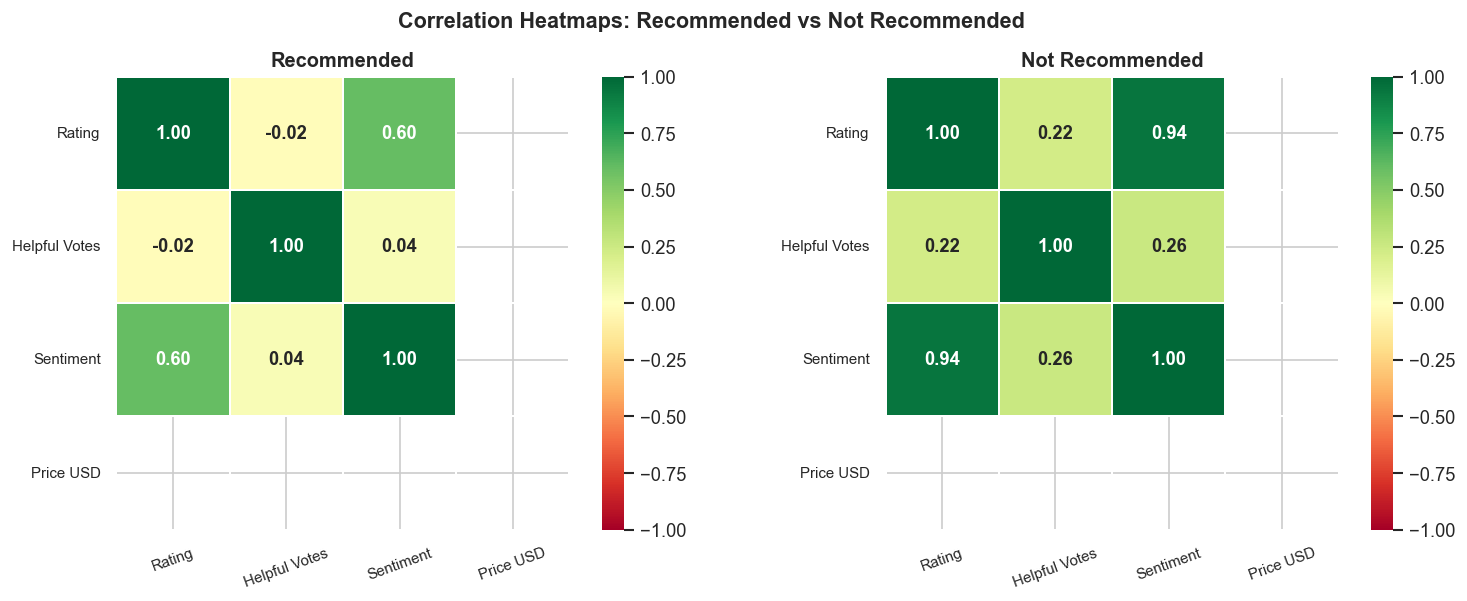

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, subset, label in zip(axes, [df_rec, df_not], ['Recommended', 'Not Recommended']):
    sub = subset.copy()
    sub['sentiment_score'] = sub['sentiment'].map({'Positive': 1, 'Neutral': 0, 'Negative': -1})
    corr = sub[['reviews.rating', 'reviews.numHelpful', 'sentiment_score', 'price_usd']].rename(columns={
        'reviews.rating': 'Rating',
        'reviews.numHelpful': 'Helpful Votes',
        'sentiment_score': 'Sentiment',
        'price_usd': 'Price USD'
    }).corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1,
                linewidths=1.2, linecolor='white', square=True,
                annot_kws={'size': 11, 'weight': 'bold'}, ax=ax)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=20, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.suptitle('Correlation Heatmaps: Recommended vs Not Recommended', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/s5_heatmap_rec_vs_not.png', dpi=150)
plt.show()
